# Exploring the Tabular Data for HECKTOR 2026



In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [10]:
rawDF = pd.read_csv('./Data/HECKTOR_2026_training_data.csv')
rawDF.head()

,PatientID,CenterID,Age,Gender,Tobacco Consumption,Alcohol Consumption,Performance Status,Treatment,HPV Status,Relapse,RFS,T-stage,N-stage
0,CHUM-001,1.0,82.0,1.0,NaN,NaN,NaN,1.0,NaN,0.0,1704.0,T2,N2
1,CHUM-002,1.0,73.0,1.0,NaN,NaN,NaN,1.0,NaN,1.0,439.0,T3,N1
2,CHUM-006,1.0,65.0,1.0,NaN,NaN,NaN,1.0,NaN,0.0,1186.0,T2,N2
3,CHUM-007,1.0,70.0,0.0,NaN,NaN,NaN,0.0,NaN,0.0,1702.0,T2,N2
4,CHUM-008,1.0,67.0,0.0,NaN,NaN,NaN,1.0,NaN,0.0,1499.0,T2,N2


In [11]:
rawDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PatientID            782 non-null    object 
 1   CenterID             782 non-null    float64
 2   Age                  782 non-null    float64
 3   Gender               782 non-null    float64
 4   Tobacco Consumption  522 non-null    float64
 5   Alcohol Consumption  516 non-null    float64
 6   Performance Status   468 non-null    float64
 7   Treatment            763 non-null    float64
 8   HPV Status           597 non-null    float64
 9   Relapse              727 non-null    float64
 10  RFS                  727 non-null    float64
 11  T-stage              778 non-null    object 
 12  N-stage              782 non-null    object 
dtypes: float64(10), object(3)
memory usage: 79.6+ KB


In [12]:
rawDF.describe()

,CenterID,Age,Gender,Tobacco Consumption,Alcohol Consumption,Performance Status,Treatment,HPV Status,Relapse,RFS
count,782.000000,782.000000,782.000000,522.000000,516.000000,468.000000,763.000000,597.000000,727.000000,727.000000
mean,4.335038,59.987468,0.835038,0.461686,0.637597,0.621795,0.836173,0.892797,0.203576,1638.778542
std,1.514006,9.211646,0.371383,0.499008,0.481161,0.725872,0.370361,0.309630,0.402935,1200.289138
min,1.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000
25%,3.000000,53.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,715.000000
50%,5.000000,59.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1295.000000
75%,5.000000,66.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2545.500000
max,8.000000,90.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,5888.000000


In [13]:
rawDF.isnull().sum()

PatientID                0
CenterID                 0
Age                      0
Gender                   0
Tobacco Consumption    260
Alcohol Consumption    266
Performance Status     314
Treatment               19
HPV Status             185
Relapse                 55
RFS                     55
T-stage                  4
N-stage                  0
dtype: int64

## Visualizations

Quick plots to see what we're working with. Main focus: missing values and label balance.

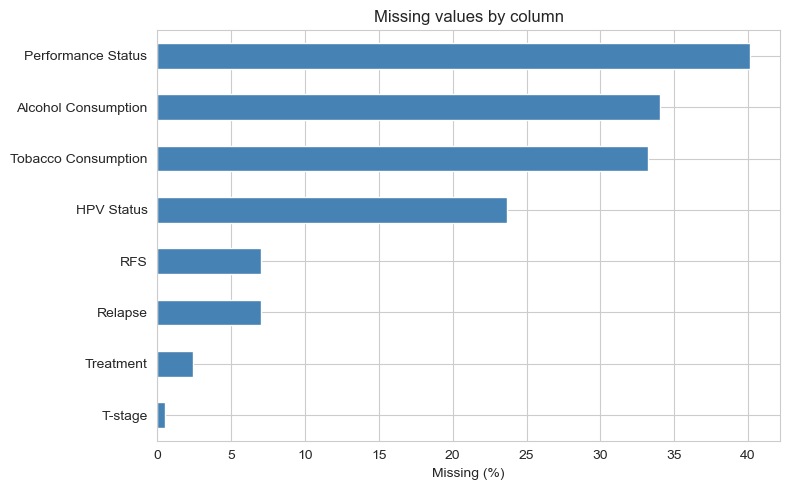

Rows: 782
T-stage                 0.5
Treatment               2.4
Relapse                 7.0
RFS                     7.0
HPV Status             23.7
Tobacco Consumption    33.2
Alcohol Consumption    34.0
Performance Status     40.2
dtype: float64


In [14]:
# Missing values per column (%)
missing_pct = (rawDF.isnull().mean() * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(8, 5))
missing_pct.plot(kind="barh", color="steelblue")
plt.xlabel("Missing (%)")
plt.title("Missing values by column")
plt.tight_layout()
plt.show()

print("Rows:", len(rawDF))
print(missing_pct.round(1))

In [15]:
# How complete is each row?
clinical_cols = [
    "Tobacco Consumption", "Alcohol Consumption",
    "Performance Status", "Treatment", "HPV Status",
]

all_clinical = rawDF[clinical_cols].notna().all(axis=1).sum()
all_tn = rawDF[["T-stage", "N-stage"]].notna().all(axis=1).sum()
all_rfs = rawDF[["Relapse", "RFS"]].notna().all(axis=1).sum()

summary = pd.Series({
    "All clinical features present": all_clinical,
    "T-stage + N-stage present": all_tn,
    "Relapse + RFS present": all_rfs,
    "Total patients": len(rawDF),
})

print(summary)
print()
print("Usable for Task 2 (TN staging):", all_tn)
print("Usable for Task 3 (prognosis):", all_rfs)

All clinical features present    451
T-stage + N-stage present        778
Relapse + RFS present            727
Total patients                   782
dtype: int64

Usable for Task 2 (TN staging): 778
Usable for Task 3 (prognosis): 727


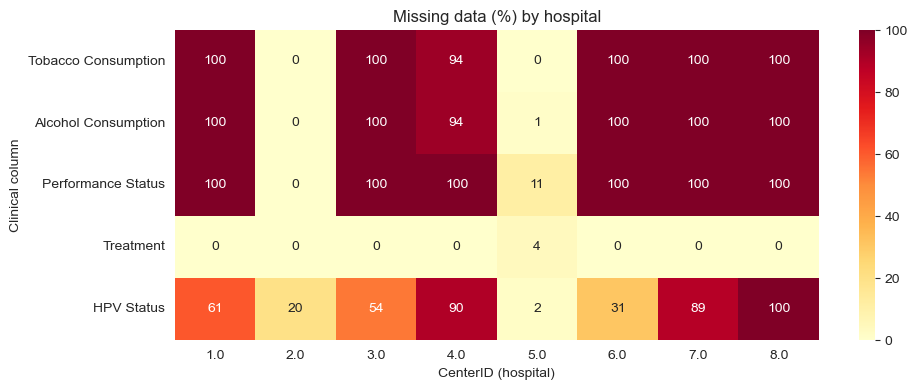

In [16]:
# Are certain hospitals missing more clinical data than others?
# Each CenterID is a different hospital that contributed patients.

columns_with_gaps = [
    "Tobacco Consumption",
    "Alcohol Consumption",
    "Performance Status",
    "Treatment",
    "HPV Status",
]

centers = sorted(rawDF["CenterID"].dropna().unique())
missing_pct_by_hospital = pd.DataFrame(index=columns_with_gaps, columns=centers, dtype=float)

for center in centers:
    patients_at_center = rawDF[rawDF["CenterID"] == center]
    total = len(patients_at_center)

    for col in columns_with_gaps:
        how_many_missing = patients_at_center[col].isna().sum()
        pct = (how_many_missing / total) * 100
        missing_pct_by_hospital.loc[col, center] = float(pct)

plt.figure(figsize=(10, 4))
sns.heatmap(missing_pct_by_hospital.astype(float), annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Missing data (%) by hospital")
plt.xlabel("CenterID (hospital)")
plt.ylabel("Clinical column")
plt.tight_layout()
plt.show()

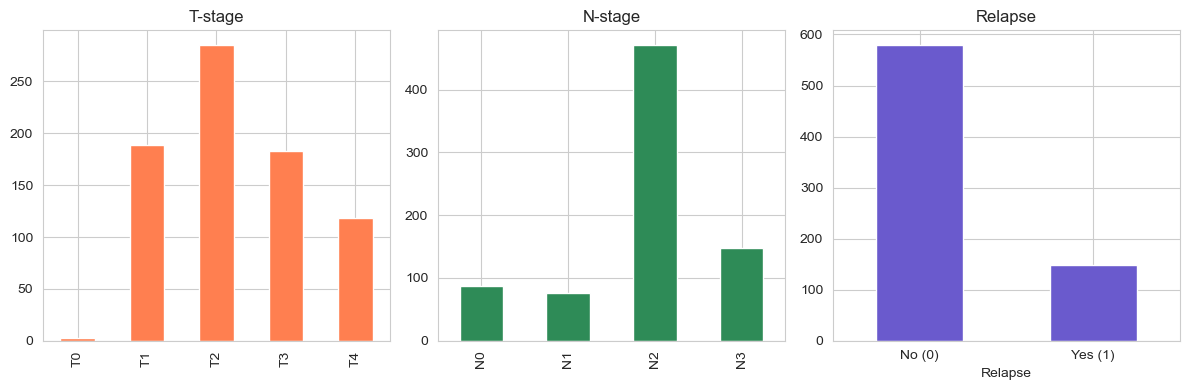

Relapse rate: 0.204
Median RFS (days): 1295.0


In [17]:
# Label distributions (Tasks 2 and 3)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

rawDF["T-stage"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="coral")
axes[0].set_title("T-stage")
axes[0].set_xlabel("")

rawDF["N-stage"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("N-stage")
axes[1].set_xlabel("")

rawDF["Relapse"].value_counts().sort_index().plot(kind="bar", ax=axes[2], color="slateblue")
axes[2].set_title("Relapse")
axes[2].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)

plt.tight_layout()
plt.show()

print("Relapse rate:", rawDF["Relapse"].mean().round(3))
print("Median RFS (days):", rawDF["RFS"].median())

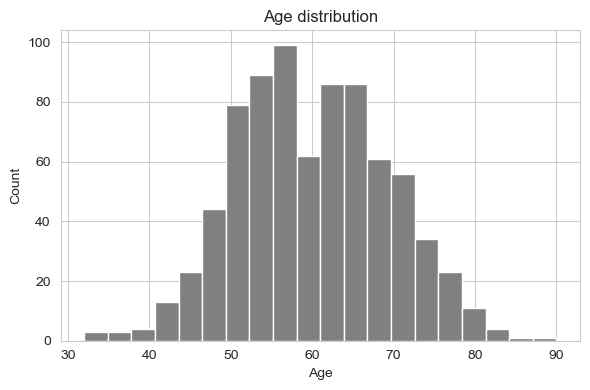

In [18]:
# Age distribution (only column with no missing values besides IDs)
plt.figure(figsize=(6, 4))
rawDF["Age"].hist(bins=20, color="gray", edgecolor="white")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age distribution")
plt.tight_layout()
plt.show()